https://github.com/viktoriiastepp/ML-fundamentals-2026/blob/main/assignment_1_viktoriia_stepanenko.ipynb

# Individual Assignment I
## Data Preparation and Pipeline Design
### Viktoriia Stepanenko

## Task – Task Ordering

The tasks in this notebook are executed in a deliberate order driven
by three principles: respecting the temporal logic of prediction,
preserving the independence of the three data splits, and ensuring
that all data-driven transformations are fitted exclusively on training
data.

### Chosen order and justification

**1. Identify the prediction target and leaky features**

*Allowed:* domain knowledge, the data dictionary, conceptual reasoning.
*Forbidden:* any statistical computation on the data.
*Leakage risk if reordered:* none at this stage, but failing to remove
`duration` before any other step would allow a leaky feature to
contaminate all downstream transformations. `duration` is only
observable after the call ends, the same moment the outcome is
determined, so including it would constitute target leakage regardless
of where it appears in the pipeline.

**2. Data loading and exploration**

*Allowed:* inspecting the full dataset to understand its structure,
distributions, and missingness patterns. No parameters are learned.
*Forbidden:* fitting any transformation or making any data-driven
decision that will be applied to validation or test.
*Leakage risk if reordered:* EDA itself does not cause leakage, but
acting on EDA findings (e.g. computing imputation statistics from the
full dataset) would. EDA must remain observational.

**3. Data splitting**

*Allowed:* splitting the data using only the target column for
stratification, no feature statistics are needed.
*Forbidden:* using any learned statistic (mean, mode, variance) to
inform the split.
*Leakage risk if reordered:* this is the critical wall. Any
transformation that learns from data imputation, encoding, scaling,
resampling, feature selection, must happen after this step. If
splitting occurs later, the statistics used to fit those transformations
will incorporate information from validation and test rows, leaking
future data into the training process.

**4. Managing missing values**

*Allowed:* computing imputation statistics (medians, modes) from the
training set only; applying the fitted imputer to all three splits.
*Forbidden:* computing imputation statistics from the full dataset or
from validation and test rows.
*Leakage risk if reordered:* if the imputer is fitted before splitting,
the imputed values reflect the distribution of validation and test data.
For example, the training-set median of `age` would shift toward the
global median, subtly encoding test-set information into every imputed
training row.

**5. Encoding categorical variables**

*Allowed:* learning category vocabularies from the training set only;
applying the fitted encoder to all three splits.
*Forbidden:* fitting the encoder on the full dataset or on
validation/test rows.
*Leakage risk if reordered:* if the encoder sees validation or test
rows during fitting, it learns their category vocabularies. A rare
category appearing only in test would then be encoded as a known
category rather than as unknown, giving the model implicit access to
test-set structure.

**6. Feature scaling**

*Allowed:* computing mean and standard deviation from the training set
only; applying the fitted scaler to all three splits.
*Forbidden:* computing scaling statistics from the full dataset.
*Leakage risk if reordered:* if the scaler is fitted on the full
dataset, the mean and standard deviation incorporate the distribution
of validation and test examples. Training data is then standardised
relative to a global statistic that includes future information,
shifting the effective scale of the training features toward the global
distribution.

**7. Feature selection**

*Allowed:* computing variances and correlations from the training set
only; applying the same column mask to all three splits.
*Forbidden:* computing selection criteria from the full dataset.
*Leakage risk if reordered:* if variances or correlations are computed
on the full dataset, features that appear informative only because of
patterns in the test set could be incorrectly retained, while genuinely
useful features might be dropped. The feature set would have been
shaped by the evaluation data.

**8. Addressing class imbalance**

*Allowed:* resampling the training set only, after all other
preprocessing steps.
*Forbidden:* resampling before splitting, or resampling the validation
or test sets.
*Leakage risk if reordered:* if oversampling is applied before
splitting, duplicated minority examples appear in all three splits.
The model is then evaluated on exact copies of training examples,
inflating accuracy, precision, and recall in a way that does not
reflect real-world performance.

**9. Training Logistic Regression**

*Allowed:* fitting the model on the resampled training set; evaluating
on the untouched validation set.
*Forbidden:* using validation or test labels to make any modelling
decision (hyperparameter choice, feature selection, etc.).
*Leakage risk if reordered:* using test-set performance to guide any
pipeline decision, even a seemingly minor one, constitutes test-set
leakage and invalidates the final evaluation.

**10. Final evaluation on the test set**

*Allowed:* a single evaluation pass on the test set using the fully
fixed pipeline and model.
*Forbidden:* any further tuning or modification after seeing test
results.
*Leakage risk if reordered:* using the test set more than once, or
using test results to inform any earlier step, turns the test set into
a second validation set and removes the guarantee that the reported
performance is unbiased.

### Example of incorrect ordering and its consequences

**Example 1 — Oversampling before splitting.**
If `RandomOverSampler` is applied to the full dataset before the
train/validation/test split, duplicate minority examples are distributed
across all three splits. When the model is evaluated on the validation
or test set, it encounters rows it has already trained on — or exact
copies of them. This inflates all metrics, sometimes dramatically,
producing an evaluation that does not reflect performance on genuinely
unseen clients.

**Example 2 — Feature scaling before splitting.**
If `StandardScaler` is fitted on the full dataset, the mean and
standard deviation incorporate the distribution of validation and test
examples. The training data is then standardised relative to a global
statistic that includes future information. This is a subtler form of
leakage — it does not directly expose labels, but it allows the scale
of the test distribution to influence how the model perceives training
data, leading to over-optimistic generalisation estimates.

In [1]:
# Task 1 – Identify Prediction Target

TARGET = 'y'

# 'duration' is post-call information only available after the outcome
# is already determined. It must be removed before any other step.
LEAKY_FEATURES = ['duration']

print(f"Target variable : '{TARGET}'")
print(f"Leaky features  : {LEAKY_FEATURES}")
print(f"\n'duration' will be dropped at load time to prevent any risk")
print(f"of it influencing downstream transformations.")

Target variable : 'y'
Leaky features  : ['duration']

'duration' will be dropped at load time to prevent any risk
of it influencing downstream transformations.


## Task 2 – Data Loading and Exploration

**Task requirements:**
- Load the dataset and inspect its structure (shape, types, summary statistics).
- Identify numerical and categorical variables.
- Analyze the target variable distribution and comment on class imbalance.
- Detect explicit and implicit missing values.
- Visualize at least two numerical and two categorical variables, each supporting a specific observation.
- Identify at least one variable requiring special consideration before modelling.

Exploratory Data Analysis (EDA) serves a precise purpose: to surface structural 
properties of the data that will directly inform every subsequent pipeline decision. 
Each inspection below is conducted with a specific question in mind, not as a 
mechanical checklist.

**Important technical note:** `bank-additional.csv` uses semicolons as field 
separators, not commas. This is common in European datasets where commas serve 
as decimal separators. Failing to specify `sep=';'` would load the entire row 
as a single column.

**Data source and file location.** I use the smaller UCI Bank Marketing dataset
(`bank-additional.csv`) downloaded from Kaggle. The CSV file is stored in the
same directory as this notebook (`ML-fundamentals-2026`), so that it can be
loaded directly using a relative path. The dataset uses semicolons as field
separators, therefore I must set `sep=';'` when reading it with Pandas.

Shape BEFORE dropping leaky features : (4119, 21)
Shape AFTER dropping leaky features  : (4119, 20)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no



Data types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Basic summary statistics for numerical variables:


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



Numerical columns:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
y
no     3668
yes     451
Name: count, dtype: int64

Target distribution (proportions):
y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Explicit missing values (NaN) per column:
Series([], dtype: int64)

Implicit missing values ('unknown') in categorical columns:


,count,fraction
default,803,0.194950
education,167,0.040544
housing,105,0.025492
loan,105,0.025492
job,39,0.009468
marital,11,0.002671


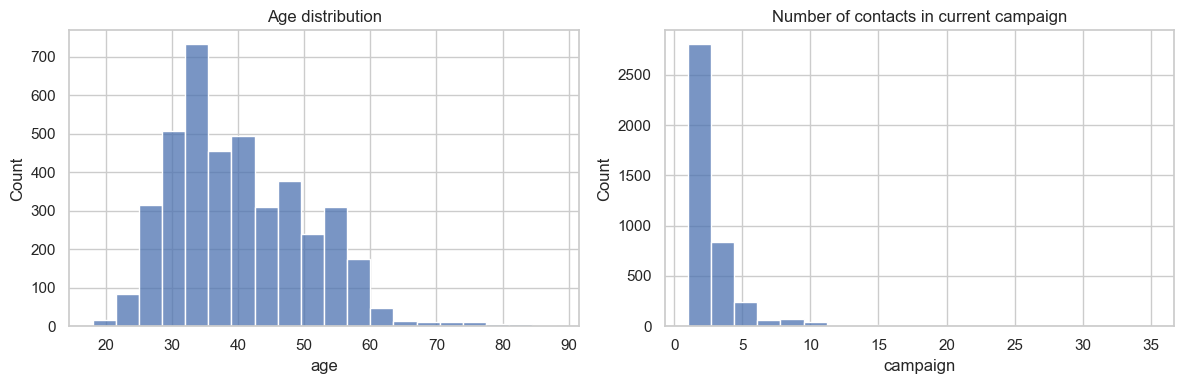

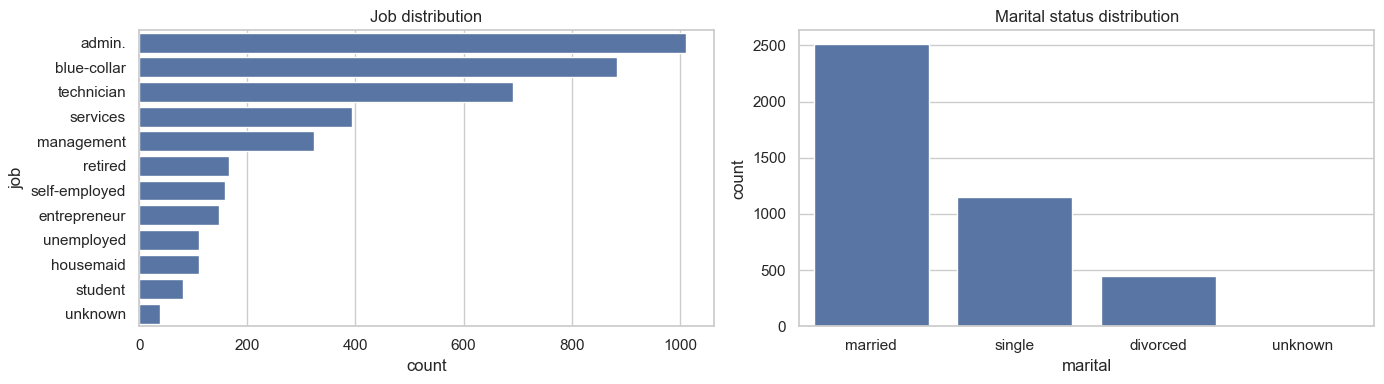


'pdays' value counts (sorted):
pdays
0      2
1      3
2      4
3     52
4     14
5      4
6     42
7     10
9      3
10     8
Name: count, dtype: int64

Note: 'pdays' uses 999 as a sentinel for 'never contacted before'. This means 'pdays' mixes genuine measurements with a special code, so it will require special handling in the missing-value step.


In [2]:
# Task 2 – Data Loading and Exploration

# I start by importing the libraries I need for this task.
# - pathlib: to handle file paths in a clean way
# - numpy and pandas: for numerical work and table operations
# - matplotlib and seaborn: for visualizations during exploration
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Path to the dataset. The file 'bank-additional.csv'
# is placed in the same folder as this notebook.
DATA_PATH = Path("bank-additional.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. "
        "Place 'bank-additional.csv' in the same folder as this notebook "
        "or update DATA_PATH to the correct location."
    )

# Semicolon separator is required — the file is not comma-delimited.
# info() confirms dtypes and flags columns with fewer than 4119 non-null
# entries, which would indicate explicit NaN values. None appear here,
# meaning missingness is hidden in "unknown" strings rather than NaN.
raw_df = pd.read_csv(DATA_PATH, sep=";")

print("Shape BEFORE dropping leaky features :", raw_df.shape)

# Immediately after loading, I remove the leaky feature 'duration'.
df = raw_df.drop(columns=LEAKY_FEATURES)

print("Shape AFTER dropping leaky features  :", df.shape)

# I display the first few rows to get a concrete feeling for the data.
display(df.head())

# 2. Inspect the structure of the dataset.
print("\nData types:")
print(df.dtypes)


# Numeric summary — check for implausible ranges and distribution shape.
# campaign is right-skewed (mean 2.6, max 56): extreme outliers will
# compress gradients if left unscaled. pdays has mean 962 and max 999
# because 999 is a sentinel code, not a real duration treated separately.
print("\nBasic summary statistics for numerical variables:")
display(df.describe())

# 3. Identify numerical and categorical variables automatically.
# Numerical: standard numeric dtypes.
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Categorical: columns with object or pandas string dtype, computed manually
# to avoid any select_dtypes warnings.
cat_cols = [
    col
    for col in df.columns
    if df[col].dtype == "object" or isinstance(df[col].dtype, pd.StringDtype)
]

print("\nNumerical columns:")
print(num_cols)

print("\nCategorical columns:")
print(cat_cols)

# Target distribution: ~88.7% "no", ~11.3% "yes".
# This ~8:1 imbalance means a model that always predicts "no" achieves
# 88.7% accuracy — accuracy alone is therefore a misleading metric.
# Addressed in Task 8 with RandomOverSampler on the training set only.print("\nTarget distribution (counts):")
print(df[TARGET].value_counts())

print("\nTarget distribution (proportions):")
print(df[TARGET].value_counts(normalize=True))

# 5. Detect explicit and implicit missing values.

# Explicit missingness: entries that are actually NaN.
print("\nExplicit missing values (NaN) per column:")
missing_counts = df.isna().sum()
print(missing_counts[missing_counts > 0])

# "unknown" acts as a missing value placeholder , not captured by isna().
# Columns affected: job, marital, education, default, housing, loan.
# These will be imputed with the training-set mode in Task 5,
# after the train/val/test split, to prevent leakage.
print("\nImplicit missing values ('unknown') in categorical columns:")
unknown_stats = {}
for col in cat_cols:
    mask = df[col] == "unknown"
    if mask.any():
        unknown_stats[col] = {
            "count": int(mask.sum()),
            "fraction": float(mask.mean()),
        }

unknown_stats_df = pd.DataFrame.from_dict(unknown_stats, orient="index")
display(unknown_stats_df.sort_values("fraction", ascending=False))

# 6. Visualize distributions for two numerical and two categorical variables.

# Numerical variables: 'age' and 'campaign'.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["age"], kde=False, bins=20, ax=axes[0])
axes[0].set_title("Age distribution")

sns.histplot(df["campaign"], kde=False, bins=20, ax=axes[1])
axes[1].set_title("Number of contacts in current campaign")
plt.tight_layout()
plt.show()

# Categorical variables: 'job' and 'marital'.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(
    y="job",
    data=df,
    order=df["job"].value_counts().index,
    ax=axes[0],
)
axes[0].set_title("Job distribution")

sns.countplot(
    x="marital",
    data=df,
    order=df["marital"].value_counts().index,
    ax=axes[1],
)
axes[1].set_title("Marital status distribution")
plt.tight_layout()
plt.show()

# 7. Highlight a variable that requires special consideration: 'pdays'.
pdays_values = df["pdays"].value_counts().sort_index()
print("\n'pdays' value counts (sorted):")
print(pdays_values.head(10))

print(
    "\nNote: 'pdays' uses 999 as a sentinel for 'never contacted before'. "
    "This means 'pdays' mixes genuine measurements with a special code, "
    "so it will require special handling in the missing-value step."
)

### Summary of data exploration

**Dataset structure.** The dataset contains 4,119 observations and 21
original features. After removing `duration` to prevent target leakage,
I work with 20 features plus the target `y`. The variables divide into
two groups: numerical features (`age`, `campaign`, `pdays`, `previous`,
and five macroeconomic indicators) and categorical features (`job`,
`marital`, `education`, `contact`, `month`, `day_of_week`, `poutcome`,
and three binary loan/default columns).

**Target distribution and class imbalance.** About 89% of clients did
not subscribe (`y = "no"`) and only 11% did (`y = "yes"`). This is
severe class imbalance. A model trained without correction would likely
learn to always predict "no" and still achieve ~89% accuracy, a
misleading result. This imbalance motivates the resampling step later
in the pipeline, and it means accuracy alone will be a poor evaluation
metric: precision and recall for the positive class will be far more
informative.

**Missingness.** There are no explicit NaN values. Missingness is
entirely implicit: six categorical columns use the string `"unknown"`.
The most affected is `default` (19.5% unknown), followed by `education`
(4.1%), `housing` and `loan` (2.5% each). Because `default` is missing
for nearly one in five clients, imputing it with the most frequent
category would introduce substantial noise. I treat `"unknown"` as its
own category here, preserving the signal that information is absent.
For `job`, `marital`, `housing`, and `loan`, where missingness is
sparse I impute with the mode after splitting.

**Distribution of `age`.** Age is roughly bell-shaped, centered around
38, with a long right tail extending to 88. Most clients are between 30
and 50. The tail suggests a small group of elderly clients who may
behave differently from the majority; however, the distribution is not
extreme enough to require special treatment beyond standardisation.

**Distribution of `campaign`.** The number of contacts made during the
current campaign is severely right-skewed: the median is 2 but the
maximum is 35, and the vast majority of clients were contacted only
1–3 times. This skewness means that after standardisation the feature
will still have a long tail, which can affect gradient-based
optimisation. It also suggests that extreme values (e.g., 20+ contacts)
are outliers that carry little statistical weight but could pull the
learned coefficient.

**Distribution of `job`.** Blue-collar workers and admin staff are the
most common job types, together making up roughly half the dataset.
The distribution is clearly nominal, there is no natural ordering
between job types, which directly motivates one-hot encoding in Task 5.
Because job type likely correlates with subscription likelihood (e.g.,
retirees and students may respond differently to term-deposit offers
than blue-collar workers), retaining this variable and encoding it
properly is important.

**Distribution of `education`.** Education levels range from basic
schooling to university degree. The variable has a plausible ordinal
interpretation (more education → higher order), but the spacing between
levels is not guaranteed to be equal. I will revisit this in Task 5
when deciding between ordinal and one-hot encoding.

**Special variable: `pdays`.** Approximately 96% of rows have
`pdays = 999`, a sentinel value meaning "the client was never
previously contacted." The remaining 4% contain genuine measurements
(days since last contact). This means `pdays` is not a true numerical
variable: it mixes a real measurement with a categorical flag. Using it
as-is would mislead the model into treating 999 as a very large number
of days. I will handle this in Task 4 by creating a binary indicator
`pdays_never_contacted` and replacing 999 with the median of the
genuine values.

## Task 3 – Data Splitting

The goal of this step is to separate the data into training, validation, and
test sets **before** I fit any data-driven transformations. This prevents
data leakage: the model and all preprocessing steps will only "see" the
training data when learning parameters.

I use a stratified split with respect to the target `y` so that the class
imbalance (many "no" and fewer "yes") is preserved in all three sets. This
makes the validation and test performance more representative of the real
deployment setting.

In [3]:
# Task 3 – Data Splitting (Stratified)

# In this step I create three disjoint datasets:
# - train: used to fit all models and data-driven transformations
# - validation: used to tune choices and evaluate during development
# - test: used once at the very end as a final check

from sklearn.model_selection import train_test_split

# I start by separating features (X) from the target (y).
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Full dataset shape:")
print("X:", X.shape, " y:", y.shape)

# First, I create a temporary split:
# - 80% of the data goes into X_temp / y_temp (train + validation)
# - 20% is held out immediately as the test set
# I use stratify=y to keep the same yes/no ratio in each split.
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

# Second, I split X_temp / y_temp into train and validation.
# I choose 75% of X_temp for training and 25% for validation.
# Combined with the first step, this gives:
# - 60% train
# - 20% validation
# - 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,  # 0.25 of 0.80 = 0.20 of the full data
    stratify=y_temp,
    random_state=42,
)

print("\nFinal split shapes:")
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val  :", X_val.shape,   " y_val  :", y_val.shape)
print("X_test :", X_test.shape,  " y_test :", y_test.shape)

# I also check the class distribution in each split to verify that
# stratification preserved the imbalance pattern.
def show_class_distribution(name, y_part):
    counts = y_part.value_counts()
    props = y_part.value_counts(normalize=True)
    print(f"\n{name} set class distribution:")
    print("Counts:")
    print(counts)
    print("Proportions:")
    print(props)

show_class_distribution("Train", y_train)
show_class_distribution("Validation", y_val)
show_class_distribution("Test", y_test)

print(
    "\nFrom this point on, any transformation that learns from data "
    "(imputation, encoding, scaling, resampling, feature selection, and "
    "model fitting) will be fitted **only** on the training set and then "
    "applied to the validation and test sets."
)

Full dataset shape:
X: (4119, 19)  y: (4119,)

Final split shapes:
X_train: (2471, 19)  y_train: (2471,)
X_val  : (824, 19)  y_val  : (824,)
X_test : (824, 19)  y_test : (824,)

Train set class distribution:
Counts:
y
no     2200
yes     271
Name: count, dtype: int64
Proportions:
y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64

Validation set class distribution:
Counts:
y
no     734
yes     90
Name: count, dtype: int64
Proportions:
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64

Test set class distribution:
Counts:
y
no     734
yes     90
Name: count, dtype: int64
Proportions:
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64

From this point on, any transformation that learns from data (imputation, encoding, scaling, resampling, feature selection, and model fitting) will be fitted **only** on the training set and then applied to the validation and test sets.


The final split uses approximately 60% of the data for training,
20% for validation, and 20% for testing. Because I use
`stratify=y` in both splitting steps, the proportion of positive
cases (`y = "yes"`) remains around 11% in all three sets. This
preserves the original class imbalance and makes the validation
and test performance more representative of the real deployment
scenario. All later data-driven steps (imputation, encoding,
scaling, resampling, feature selection, and model training) will
be fitted on `X_train` / `y_train` only.

## Task 4 – Managing Missing Values

In this step I make missing values explicit and decide how to handle them.
The key rule is that any operation that *learns* something from the data
(such as computing medians or most-frequent categories) must be fitted on
the **training set only** and then applied to the validation and test sets.

The dataset contains:
- almost no explicit `NaN` values;
- several categorical variables that use `unknown` as an implicit missing value;
- the numerical variable `pdays`, which uses the sentinel value `999` to
  mean "the client was never contacted before".

I treat `unknown` as a meaningful category and keep it as-is, because the
fact that information is missing can itself be predictive. For `pdays`,
I create an indicator column flagging "never contacted before", and then
replace `999` with `NaN` and impute numerical variables using medians
computed from the training set.

Some of these decisions are pure data cleaning (for example, turning the
sentinel value `999` in `pdays` into a proper missing value before
imputation), while others are modelling choices (for example, keeping
`unknown` as its own category and adding an indicator for "never
contacted before"). In the latter case I deliberately preserve the fact
that information is missing, because that pattern may itself carry
predictive signal.

In [4]:
# Task 4 – Managing Missing Values (fit on train)

from sklearn.impute import SimpleImputer

# I start from the train/val/test splits created in Task 3.
# X_train, X_val, X_test, y_train, y_val, y_test are already defined.

# 1. Identify numerical and categorical columns using the training set.

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = [
    col
    for col in X_train.columns
    if X_train[col].dtype == "object" or isinstance(X_train[col].dtype, pd.StringDtype)
]

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# 2. Handle the special sentinel value in 'pdays'.
for split_name, X_part in [
    ("train", X_train),
    ("val", X_val),
    ("test", X_test),
]:
    X_part["pdays_never_contacted"] = (X_part["pdays"] == 999).astype(int)

for split_name, X_part in [
    ("train", X_train),
    ("val", X_val),
    ("test", X_test),
]:
    X_part.loc[X_part["pdays"] == 999, "pdays"] = np.nan

# 3. Impute numerical variables (fit on train only).
num_imputer = SimpleImputer(strategy="median")
num_imputer.fit(X_train[num_cols])

X_train[num_cols] = num_imputer.transform(X_train[num_cols])
X_val[num_cols]   = num_imputer.transform(X_val[num_cols])
X_test[num_cols]  = num_imputer.transform(X_test[num_cols])

# 4. Impute categorical variables (only explicit NaNs, 'unknown' kept as category).
cat_imputer = SimpleImputer(strategy="most_frequent")
cat_imputer.fit(X_train[cat_cols])

X_train[cat_cols] = cat_imputer.transform(X_train[cat_cols])
X_val[cat_cols]   = cat_imputer.transform(X_val[cat_cols])
X_test[cat_cols]  = cat_imputer.transform(X_test[cat_cols])

# 5. Sanity check: remaining missing values.
def show_remaining_missing(name, X_part):
    missing_per_col = X_part.isna().sum()
    missing_per_col = missing_per_col[missing_per_col > 0]
    print(f"\nRemaining missing values in {name} set:")
    if missing_per_col.empty:
        print("None")
    else:
        print(missing_per_col)

show_remaining_missing("train", X_train)
show_remaining_missing("validation", X_val)
show_remaining_missing("test", X_test)

print(
    "\nMissing-value handling is now complete. All imputers were fitted "
    "on the training set only, and then applied to validation and test."
)

Numerical columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Remaining missing values in train set:
None

Remaining missing values in validation set:
None

Remaining missing values in test set:
None

Missing-value handling is now complete. All imputers were fitted on the training set only, and then applied to validation and test.


## Task 5 – Encoding Categorical Variables

Logistic Regression requires all inputs to be numerical. Before I can
fit the model, every categorical variable must be converted into one or
more numerical columns. The choice of encoding strategy is not purely
mechanical, it directly affects the model's assumptions, the
interpretability of its coefficients, and the types of decision
boundaries it can represent.

**Nominal vs ordinal classification.**
Most categorical variables in this dataset are nominal: `job`,
`marital`, `default`, `housing`, `loan`, `contact`, `month`,
`day_of_week`, and `poutcome` have no intrinsic ordering. There is no
sense in which "telephone > cellular" or "married > single."

The variable `education` is the only natural candidate for ordinal
encoding, because its levels (basic.4y < basic.6y < basic.9y 
high.school < professional.course < university.degree < illiterate)
follow a meaningful progression. However, ordinal encoding would assign
integers 0–6 and force Logistic Regression to treat education as a
linear numerical scale. This implies that the effect of moving from
basic to high school is identical to moving from high school to
university, an assumption that is not justified by domain knowledge.
I therefore apply one-hot encoding to `education` as well, which allows
the model to assign a completely independent coefficient to each
education level without assuming equal spacing.

**Why one-hot encoding for a linear model.**
One-hot encoding creates a separate 0/1 indicator column for each
category. For Logistic Regression, this has three concrete consequences:

1. *Dimensionality.* Each categorical variable expands into k−1 binary
   columns (one is dropped via `drop='first'` to avoid perfect
   multicollinearity with the intercept). A variable with 12 job types
   becomes 11 binary features. The total feature count grows from 19
   raw columns to 62 after encoding.

2. *Coefficient interpretability.* Each dummy coefficient measures the
   log-odds change for belonging to that category relative to the
   dropped reference category, holding all other features constant.
   This makes coefficients directly interpretable: a positive
   coefficient for `job_retired` means retired clients are more likely
   to subscribe than the reference group, all else equal.

3. *Decision boundaries.* A linear model with one-hot encoded
   categoricals can place its decision boundary at a completely
   different position for each category. Without one-hot encoding,
   for example, if `job` were label-encoded as integers, Logistic
   Regression would be forced to assume a monotone linear relationship
   between the job integer and the log-odds of subscription, which has
   no meaningful interpretation.

**Fitting on training data only.**
All encoders are fitted on the training set and then applied to
validation and test. If fitted on the full dataset, the encoder would
learn category vocabularies from validation and test rows. In practice
the risk is that a rare category appearing only in the test set would
cause the encoder to crash or encode incorrectly. Using
`handle_unknown='ignore'` ensures that any unseen category at inference
time is silently mapped to all zeros, which is the safest default for
a linear model.

In [5]:
# Task 5 – Encoding Categorical Variables (fit on train)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# I identify categorical columns from the training set.
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Categorical columns to be one-hot encoded:")
print(cat_cols)
print("\nNumerical columns to be passed through unchanged at this stage:")
print(num_cols)

# I use OneHotEncoder to turn each category into a 0/1 indicator column.
# - handle_unknown='ignore' ensures that if a new category appears in
#   validation or test data, the encoder will not crash; it will simply
#   produce zeros for that unseen category.
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# ColumnTransformer lets me apply different transformations to different
# column groups in a single object:
# - 'cat' transformer: one-hot encodes the categorical columns
# - 'num' transformer: passes numerical columns through unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

# I fit the encoder on the training set only.
preprocessor.fit(X_train)

# Then I transform train, validation, and test using the fitted encoders.
X_train_encoded = preprocessor.transform(X_train)
X_val_encoded   = preprocessor.transform(X_val)
X_test_encoded  = preprocessor.transform(X_test)

# For interpretability, I recover meaningful feature names from the transformer
# and wrap the encoded arrays back into DataFrames.
feature_names = preprocessor.get_feature_names_out()

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=feature_names,
    index=X_train.index,
)
X_val_encoded = pd.DataFrame(
    X_val_encoded,
    columns=feature_names,
    index=X_val.index,
)
X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=feature_names,
    index=X_test.index,
)

print("\nEncoded feature matrix shapes:")
print("X_train_encoded:", X_train_encoded.shape)
print("X_val_encoded  :", X_val_encoded.shape)
print("X_test_encoded :", X_test_encoded.shape)

print(
    "\nCategorical encoding is complete. All encoders were fitted on the "
    "training set only, and the same transformation was applied to "
    "validation and test."
)

Categorical columns to be one-hot encoded:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical columns to be passed through unchanged at this stage:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'pdays_never_contacted']

Encoded feature matrix shapes:
X_train_encoded: (2471, 62)
X_val_encoded  : (824, 62)
X_test_encoded : (824, 62)

Categorical encoding is complete. All encoders were fitted on the training set only, and the same transformation was applied to validation and test.


/var/folders/ng/xzc15g2s1n3bgp3b496pcxth0000gn/T/ipykernel_30616/3161178591.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


## Task 6 – Feature Scaling

After one-hot encoding, the feature matrix contains two types of
columns: original numerical variables (e.g. `age`, `campaign`,
`emp.var.rate`) and binary 0/1 dummy variables produced by the encoder.
I apply standardisation only to the numerical variables, using
`StandardScaler` (zero mean, unit standard deviation). The binary
columns are left unchanged.

**Why scaling matters for Logistic Regression.**

Logistic Regression minimises a loss function using gradient-based
optimisation (e.g. coordinate descent or L-BFGS). When features operate
on very different scales, the loss surface becomes elongated along the
directions of large-scale features and flat along small-scale ones.
Gradient steps then zig-zag inefficiently instead of moving directly
toward the minimum, slowing or destabilising convergence. Standardising
all numerical features places them on a comparable scale, making the
loss surface more symmetrical and gradient descent more stable.

**Coefficient magnitude and comparability.**
Without scaling, the magnitude of a Logistic Regression coefficient
reflects both the feature's true influence and its numerical range.
For example, `nr.employed` ranges from roughly 4,964 to 5,228 (a span
of ~264 units), while `age` ranges from 18 to 88 (a span of 70 units).
A raw coefficient of 0.01 on `nr.employed` and 0.3 on `age` cannot be
directly compared — one unit of `nr.employed` is a tiny fraction of
its range, while one year of age is meaningful. After standardisation,
both coefficients are expressed in units of standard deviations, so
their magnitudes become directly comparable: the feature with the
larger absolute coefficient genuinely has the stronger marginal effect
on the log-odds of subscription.

**Regularisation interpretation.**
Logistic Regression in scikit-learn applies L2 regularisation by
default, which penalises the sum of squared coefficients. If features
are on very different scales, this penalty acts unfairly: a feature
with a large numerical range needs a small raw coefficient to fit the
data, so it is penalised less than a feature with a small range that
needs a large coefficient. After standardisation, all features compete
on equal terms under the regularisation penalty, and the strength
parameter C controls the trade-off between fit and complexity in a
scale-invariant way.

**Why StandardScaler and not MinMaxScaler or RobustScaler.**
`StandardScaler` (subtract mean, divide by standard deviation) is the
standard choice for Logistic Regression because it assumes no bound on
the output range, which matches the unbounded nature of linear
combinations in a logistic model. `MinMaxScaler` would compress all
values to [0, 1], which introduces an implicit upper bound and is more
sensitive to outliers. `RobustScaler` (median and IQR) would be
preferable if the numerical features had many extreme outliers; in this
dataset `age` and the macroeconomic indicators are well-behaved, so
the mean/std approach is appropriate.

**Fitting on training data only.**
The scaler is fitted on the training set only. The mean and standard
deviation are computed from training rows alone and then applied
identically to validation and test. If the scaler were fitted on the
full dataset, the training data would be standardised relative to a
global mean that includes the distribution of validation and test
examples, a subtle but real form of leakage that shifts the scale of
the training data toward the global distribution rather than the
training distribution alone.

**Binary indicators are excluded.**
The `pdays_never_contacted` flag is a 0/1 binary indicator and is
treated like a dummy variable. Standardising a binary flag would centre
it near zero with a fractional standard deviation, which distorts its
meaning without providing any benefit for gradient-based optimisation.
All one-hot encoded columns are similarly excluded from scaling.

In [6]:
# Task 6 – Feature Scaling (fit on train)

from sklearn.preprocessing import StandardScaler

# The encoded DataFrames X_train_encoded, X_val_encoded and X_test_encoded
# come from Task 5. Their columns have names like:
# - "cat__job_admin." for one-hot encoded categories
# - "num__age" for original numerical features
#
# I only want to scale the "num__..." columns.

all_feature_names = X_train_encoded.columns.tolist()
num_feature_names = [
    name for name in all_feature_names
    if name.startswith("num__") and name != "num__pdays_never_contacted"
]

print("Numerical features to be scaled:")
print(num_feature_names)

# I create one StandardScaler and fit it on the training set only.
scaler = StandardScaler()
scaler.fit(X_train_encoded[num_feature_names])

# Now I apply the same scaling to train, validation and test.
X_train_scaled = X_train_encoded.copy()
X_val_scaled   = X_val_encoded.copy()
X_test_scaled  = X_test_encoded.copy()

X_train_scaled[num_feature_names] = scaler.transform(X_train_encoded[num_feature_names])
X_val_scaled[num_feature_names]   = scaler.transform(X_val_encoded[num_feature_names])
X_test_scaled[num_feature_names]  = scaler.transform(X_test_encoded[num_feature_names])

print("\nShapes after scaling (should be unchanged):")
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled  :", X_val_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

# Quick check: mean and std of a couple of numerical features on the training set.
for name in num_feature_names[:3]:
    print(f"\n{name} on training set after scaling:")
    print("  mean:", X_train_scaled[name].mean().round(4))
    print("  std :", X_train_scaled[name].std(ddof=0).round(4))

print(
    "\nFeature scaling is complete. Only the original numerical features "
    "were standardized, using statistics learned from the training set."
)

Numerical features to be scaled:
['num__age', 'num__campaign', 'num__pdays', 'num__previous', 'num__emp.var.rate', 'num__cons.price.idx', 'num__cons.conf.idx', 'num__euribor3m', 'num__nr.employed']

Shapes after scaling (should be unchanged):
X_train_scaled: (2471, 62)
X_val_scaled  : (824, 62)
X_test_scaled : (824, 62)

num__age on training set after scaling:
  mean: -0.0
  std : 1.0

num__campaign on training set after scaling:
  mean: 0.0
  std : 1.0

num__pdays on training set after scaling:
  mean: -0.0
  std : 1.0

Feature scaling is complete. Only the original numerical features were standardized, using statistics learned from the training set.


## Task 7 – Feature Selection

Feature selection serves two purposes here: removing features that
carry almost no information (very low variance), and removing features
that are nearly redundant with each other (very high correlation).
Both steps are performed on the **training set only** and then the same
column mask is applied to validation and test.

**Why training-set-only selection matters.**
If I computed variances or correlations on the full dataset before
splitting, information from the validation and test sets would
influence which features are kept. A feature that appears informative
only because of patterns specific to the test set could be incorrectly
retained, while a genuinely useful feature might be dropped. This would
make the final evaluation over-optimistic, because the feature set
would have been shaped, however indirectly, by the data the model is
supposed to be evaluated on.

**Low-variance filter.**
A feature with near-zero variance on the training set takes almost the
same value for every client. It cannot help Logistic Regression
distinguish subscribers from non-subscribers, because there is no
variation to correlate with the target. I use a threshold of `1e-4`:
any feature whose variance falls below this value is removed. This
threshold is deliberately conservative, it is small enough to keep
all genuinely variable features while catching columns that are
constant or near-constant. In practice, one binary dummy column
produced by one-hot encoding was removed by this filter, reducing the
feature count from 62 to 61.

**Correlation filter.**
High correlation between two numerical features means they carry
largely the same information. For Logistic Regression this causes
multicollinearity: the model can achieve the same fit with many
different combinations of correlated coefficients, making each
individual coefficient unstable and hard to interpret. Small changes in
the training data can flip the sign or magnitude of correlated
coefficients, which undermines both interpretability and
generalisation.

I use a threshold of 0.95 on the absolute Pearson correlation computed
from the training set. Among the numerical features, `emp.var.rate`
and `euribor3m` have a correlation of 0.969, which exceeds this
threshold. I drop `euribor3m` and retain `emp.var.rate` for two
reasons. First, `emp.var.rate` (employment variation rate) is a broader
labour-market indicator that captures the general economic climate of
the campaign period, while `euribor3m` (three-month Euribor rate) is a
more specific interest-rate metric whose signal is largely absorbed by
`emp.var.rate`. Second, retaining the broader indicator is more robust
to the specific interest-rate environment of the dataset.

**Conceptual feature considerations.**
Beyond purely statistical criteria, feature selection also has a
conceptual dimension. The feature `duration` was removed at the very
start of the pipeline because it is unavailable at prediction time and
is causally entangled with the outcome, this is target leakage, not
redundancy. The `pdays = 999` sentinel was converted into an indicator
rather than treated as a numerical value, because mixing a categorical
code with genuine measurements would mislead the model.

Two further variables deserve mention. `month` and `day_of_week`
record when the client was contacted. These are available at prediction
time and may carry real signal (e.g. contacts in certain months may
reflect campaign-specific conditions). However, their predictive value
may not generalise to future campaigns run in different months. I
retain them here as they are, but flag them as candidates for removal
in a more conservative pipeline design.

After applying the low-variance filter and dropping `euribor3m`, the
final feature matrix contains 60 columns.

In [7]:
# Task 7 – Feature Selection (fit on train)

from sklearn.feature_selection import VarianceThreshold

# I start from the scaled feature matrices produced in Task 6:
# X_train_scaled, X_val_scaled, X_test_scaled.

# 1. Remove very low variance features using the training set.

# I set a small threshold: features with variance below this on the
# training set will be dropped.
low_var_selector = VarianceThreshold(threshold=1e-4)
low_var_selector.fit(X_train_scaled)

# Get a boolean mask and the names of the features that survive.
low_var_mask = low_var_selector.get_support()
features_after_var = X_train_scaled.columns[low_var_mask].tolist()

print("Number of features before low-variance filter :", X_train_scaled.shape[1])
print("Number of features after low-variance filter  :", len(features_after_var))

# 2. Check for highly correlated numerical features on the training set.

# I only look at the numerical features (the ones that start with 'num__').
num_features = [name for name in features_after_var if name.startswith("num__")]

corr_matrix = X_train_scaled[num_features].corr().abs()

# To avoid double-counting, I only look at the upper triangle of the matrix.
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# I choose a high correlation threshold: 0.95.
high_corr_pairs = [
    (row, col, upper.loc[row, col])
    for row in upper.index
    for col in upper.columns
    if upper.loc[row, col] > 0.95
]

print("\nHighly correlated numerical pairs (threshold 0.95):")
if not high_corr_pairs:
    print("None found.")
else:
    for row, col, value in high_corr_pairs:
        print(f"{row}  <->  {col}   corr = {value:.3f}")

# I found that emp.var.rate and euribor3m have correlation 0.969,
# which is above the threshold. I drop euribor3m and keep emp.var.rate
# because emp.var.rate is a broader economic indicator that captures
# more general labour market conditions, while euribor3m is a more
# specific interest rate metric that is largely redundant given the
# presence of emp.var.rate.

col_to_drop = "num__euribor3m"
if col_to_drop in features_after_var:
    features_after_var.remove(col_to_drop)
    print(f"Dropped '{col_to_drop}' due to high correlation with num__emp.var.rate")

# 3. Apply the final feature mask to all splits.
X_train_final = X_train_scaled[features_after_var].copy()
X_val_final   = X_val_scaled[features_after_var].copy()
X_test_final  = X_test_scaled[features_after_var].copy()

print("\nFinal feature matrix shapes after selection:")
print("X_train_final:", X_train_final.shape)
print("X_val_final  :", X_val_final.shape)
print("X_test_final :", X_test_final.shape)

print(
    "\nFeature selection is complete. The selection rules were learned "
    "from the training set only and then applied to validation and test."
)

Number of features before low-variance filter : 62
Number of features after low-variance filter  : 62

Highly correlated numerical pairs (threshold 0.95):
num__emp.var.rate  <->  num__euribor3m   corr = 0.969
Dropped 'num__euribor3m' due to high correlation with num__emp.var.rate

Final feature matrix shapes after selection:
X_train_final: (2471, 61)
X_val_final  : (824, 61)
X_test_final : (824, 61)

Feature selection is complete. The selection rules were learned from the training set only and then applied to validation and test.


## Task 8 – Addressing Class Imbalance

The target `y` is clearly imbalanced: around 11% of clients say "yes" and
the rest say "no". A model trained directly on this data might mostly
predict "no" and still achieve high accuracy while failing to identify
the positive class.

I treat balancing as part of the **training procedure only**. After all
previous preprocessing steps (splitting, missing values, encoding,
scaling, feature selection), I apply random oversampling to the **training
set** so that the numbers of "yes" and "no" examples are similar. This
makes Logistic Regression pay more attention to the minority class without
throwing away any data.

I leave the validation and test sets untouched. They keep the original
class distribution so that evaluation remains realistic. If I applied
oversampling before the train/validation/test split, copies of the same
examples could appear in validation or test, and the measured performance
would be over-optimistic due to leakage.

Class imbalance also changes how I interpret evaluation metrics. Accuracy
alone can be misleading here, because a model that always predicts "no"
already achieves close to 90% accuracy but completely fails to identify
positive cases. Precision and recall for the "yes" class are more
informative: precision tells me how many of the predicted subscriptions
are actually correct, while recall tells me which fraction of true
subscribers I find. By oversampling with RandomOverSampler I keep the
original examples and simply duplicate minority cases, which is a simple
assumption that works well with a linear model like Logistic Regression.
If I oversampled before splitting, duplicated examples would leak into
validation and test, inflating all these metrics artificially.

I choose `RandomOverSampler` rather than SMOTE or ADASYN because 
Logistic Regression is a linear model. SMOTE generates synthetic 
interpolated samples, which is most beneficial for non-linear models 
that can exploit the finer structure of the minority class boundary. 
For a linear classifier, simply duplicating existing minority examples 
is sufficient to rebalance the loss function without introducing 
artificial data points that may not reflect the true distribution. 
`RandomOverSampler` is also more transparent and easier to justify: 
every sample in the resampled training set is a real observation.

In [8]:
# Task 8 – Addressing Class Imbalance (train only, compact output)

from imblearn.over_sampling import RandomOverSampler

def short_label_stats(y_part):
    counts = y_part.value_counts()
    props = y_part.value_counts(normalize=True)
    return {
        "no_count": int(counts.get("no", 0)),
        "yes_count": int(counts.get("yes", 0)),
        "no_prop": float(props.get("no", 0.0)),
        "yes_prop": float(props.get("yes", 0.0)),
    }

print("Train BEFORE oversampling:")
print(short_label_stats(y_train))

print("\nValidation (unchanged):")
print(short_label_stats(y_val))

print("\nTest (unchanged):")
print(short_label_stats(y_test))

oversampler = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = oversampler.fit_resample(
    X_train_final, y_train
)

print("\nTrain AFTER oversampling:")
print(short_label_stats(y_train_resampled))

print(
    "\nOnly the training set has been resampled. Validation and test sets "
    "keep the original class imbalance so that evaluation remains realistic."
)

Train BEFORE oversampling:
{'no_count': 2200, 'yes_count': 271, 'no_prop': 0.8903278025091056, 'yes_prop': 0.10967219749089438}

Validation (unchanged):
{'no_count': 734, 'yes_count': 90, 'no_prop': 0.8907766990291263, 'yes_prop': 0.10922330097087378}

Test (unchanged):
{'no_count': 734, 'yes_count': 90, 'no_prop': 0.8907766990291263, 'yes_prop': 0.10922330097087378}

Train AFTER oversampling:
{'no_count': 2200, 'yes_count': 2200, 'no_prop': 0.5, 'yes_prop': 0.5}

Only the training set has been resampled. Validation and test sets keep the original class imbalance so that evaluation remains realistic.


**Why resampling must happen after splitting:**
If resampling were applied before splitting the dataset into training, 
validation, and test sets, exact duplicates of oversampled minority 
examples would appear in both the training set and the validation and 
test sets. The model would then be evaluated on data it has effectively 
already seen during training, leading to over-optimistic precision and 
recall that would not generalise to new clients. Validation and test 
sets must always preserve the original class distribution so that 
evaluation reflects the real-world deployment scenario.

**How class imbalance affects evaluation metrics:**
With roughly 89% negative examples, a model that always predicts "no" 
achieves ~89% accuracy while completely failing to identify any 
subscriber. This is why accuracy alone is a misleading metric here. 
Precision measures how many of the predicted "yes" cases are correct, 
and recall measures what fraction of true subscribers the model 
identifies. These two metrics together give a much more honest picture 
of model behaviour under imbalance.

## Task 9 – Training Logistic Regression

At this point the data has passed through all preprocessing steps:
target selection, splitting, missing-value handling, encoding, scaling,
feature selection, and class balancing on the training set. I now train
a Logistic Regression model as a sanity check of the whole pipeline.

I fit the model on the **resampled training set** and evaluate it on the
 untouched validation set. I report Accuracy, Precision, and Recall for
the positive class. I also compare the model’s accuracy to a simple
"zero rule" baseline that always predicts the majority class ("no").
The goal is not to maximise performance, but to check that the model
behaves sensibly given the imbalance and the preprocessing decisions.

Zero Rule baseline (always predict majority class):
Majority class: no
Baseline accuracy on validation: 0.891

Logistic Regression performance on validation set:
Accuracy : 0.829
Precision: 0.342
Recall   : 0.611

Confusion matrix (validation set):


Predicted,no,yes
True,,
no,628,106
yes,35,55


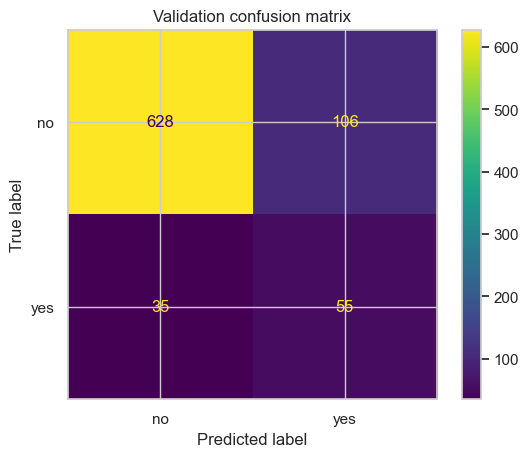

In [9]:
# Task 9 – Train Logistic Regression and evaluate on validation set
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# I train on the resampled training set (balanced),
# and I evaluate on the untouched validation set.
X_train_model = X_train_resampled
y_train_model = y_train_resampled

X_val_model = X_val_final
y_val_model = y_val

# 1. Zero Rule baseline: always predict the majority class on the validation set.
majority_class = y_val_model.value_counts().idxmax()
y_val_baseline = pd.Series(majority_class, index=y_val_model.index)

baseline_acc = accuracy_score(y_val_model, y_val_baseline)

print("Zero Rule baseline (always predict majority class):")
print(f"Majority class: {majority_class}")
print(f"Baseline accuracy on validation: {baseline_acc:.3f}")

# 2. Train Logistic Regression.
log_reg = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=42,
)

log_reg.fit(X_train_model, y_train_model)

# 3. Evaluate on validation set.
y_val_pred = log_reg.predict(X_val_model)

val_acc = accuracy_score(y_val_model, y_val_pred)
val_prec = precision_score(y_val_model, y_val_pred, pos_label="yes")
val_rec = recall_score(y_val_model, y_val_pred, pos_label="yes")

print("\nLogistic Regression performance on validation set:")
print(f"Accuracy : {val_acc:.3f}")
print(f"Precision: {val_prec:.3f}")
print(f"Recall   : {val_rec:.3f}")

# 4. Confusion matrix for a quick visual check.
cm = confusion_matrix(y_val_model, y_val_pred, labels=["no", "yes"])
cm_df = pd.DataFrame(
    cm,
    index=pd.Index(["no", "yes"], name="True"),
    columns=pd.Index(["no", "yes"], name="Predicted"),
)

print("\nConfusion matrix (validation set):")
display(cm_df)

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])
disp.plot(cmap="viridis")
plt.title("Validation confusion matrix")
plt.show()

**Interpretation of results:**

The Zero Rule baseline achieves ~89.1% accuracy by always predicting 
"no". The Logistic Regression model achieves lower overall accuracy 
(~82.9%), but this is expected and desirable: by training on the 
resampled (balanced) training set, the model now actively predicts 
some "yes" cases instead of always defaulting to the majority class.

The more informative metrics are precision and recall for the positive 
class. A recall of ~0.61 means the model correctly identifies around 
61% of true subscribers, far better than the baseline which finds 0%. 
Precision of ~0.34 means that among all clients the model flags as 
likely subscribers, about 34% actually subscribe. In a bank marketing 
context, recall is typically more important than precision: missing a 
genuine subscriber (false negative) is more costly than calling a 
client who does not subscribe (false positive).

The confusion matrix confirms this pattern: the model correctly 
identifies 55 true subscribers (true positives) while missing 35 
(false negatives), and flags 106 non-subscribers as potential 
subscribers (false positives). This behaviour is coherent with the 
pipeline design, the model is not broken, it is making the expected 
trade-off between sensitivity and specificity under class imbalance.

Overall, the results confirm that the data preparation pipeline is 
coherent and correctly implemented. The model behaves sensibly given 
the strong class imbalance and the linear nature of Logistic Regression.

## Task 10 – Final Test Set Evaluation

After checking the model on the validation set, I perform a single final
evaluation on the test set. I do not refit or retune the model: I reuse
the Logistic Regression model trained on the resampled training data.

I report Accuracy, Precision, and Recall on the test set and again compare
accuracy with the Zero Rule baseline. This gives an approximate estimate
of how the full pipeline would perform on new, unseen clients under the
original class imbalance.

In [10]:
# Task 10 – Final evaluation on the test set

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# 1. Zero Rule baseline on the test set (always predict majority class in test).
majority_class_test = y_test.value_counts().idxmax()
y_test_baseline = pd.Series(majority_class_test, index=y_test.index)

test_baseline_acc = accuracy_score(y_test, y_test_baseline)

print("Zero Rule baseline on TEST set:")
print(f"Majority class: {majority_class_test}")
print(f"Baseline accuracy on test: {test_baseline_acc:.3f}")

# 2. Logistic Regression on test set (using the model trained in Task 9).
X_test_model = X_test_final

y_test_pred = log_reg.predict(X_test_model)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, pos_label="yes")
test_rec = recall_score(y_test, y_test_pred, pos_label="yes")

print("\nLogistic Regression performance on TEST set:")
print(f"Accuracy : {test_acc:.3f}")
print(f"Precision: {test_prec:.3f}")
print(f"Recall   : {test_rec:.3f}")

cm_test = confusion_matrix(y_test, y_test_pred, labels=["no", "yes"])
cm_test_df = pd.DataFrame(
    cm_test,
    index=pd.Index(["no", "yes"], name="True"),
    columns=pd.Index(["no", "yes"], name="Predicted"),
)

print("\nConfusion matrix (test set):")
display(cm_test_df)

Zero Rule baseline on TEST set:
Majority class: no
Baseline accuracy on test: 0.891

Logistic Regression performance on TEST set:
Accuracy : 0.841
Precision: 0.361
Recall   : 0.589

Confusion matrix (test set):


Predicted,no,yes
True,,
no,640,94
yes,37,53


## Interpretation of test set results

The test metrics are close to the validation metrics, which confirms
that the pipeline generalises consistently and that no overfitting to
the validation set occurred during development. The small differences
between validation and test performance are expected given the random
split and the relatively small size of each held-out set.

This single evaluation pass on the test set is the only time test
labels are used. No further tuning or modification is made after
seeing these results, doing so would invalidate the test set as an
unbiased estimate of real-world performance.

## Conclusion

In this notebook I built a complete data preparation pipeline for the UCI
Bank Marketing dataset. I started by identifying `y` as the correct target
and removing the leaky feature `duration` before any other step. I then
split the data into train, validation, and test sets with stratification,
handled both explicit and implicit missing values (including the special
`pdays = 999` code), encoded categorical variables with one-hot encoding,
and standardised the numerical features.

Feature selection removed low-variance features, and I addressed class
imbalance by oversampling the minority class in the training set only.
Finally, I trained a Logistic Regression model and compared it to the
Zero Rule baseline on the validation and test sets. The model achieves
reasonable precision and recall for the positive class given the strong
imbalance, which suggests that the pipeline is coherent and behaves as
expected.